In [ ]:
pip install ucimlrepo

In [ ]:
#P18
from ucimlrepo import fetch_ucirepo

# fetch dataset
wine_quality = fetch_ucirepo(id=186)

# data (as pandas dataframes)
X = wine_quality.data.features
y = wine_quality.data.targets

# metadata
print(wine_quality.metadata)

# variable information
print(wine_quality.variables)


{'uci_id': 186, 'name': 'Wine Quality', 'repository_url': 'https://archive.ics.uci.edu/dataset/186/wine+quality', 'data_url': 'https://archive.ics.uci.edu/static/public/186/data.csv', 'abstract': 'Two datasets are included, related to red and white vinho verde wine samples, from the north of Portugal. The goal is to model wine quality based on physicochemical tests (see [Cortez et al., 2009], http://www3.dsi.uminho.pt/pcortez/wine/).', 'area': 'Business', 'tasks': ['Classification', 'Regression'], 'characteristics': ['Multivariate'], 'num_instances': 4898, 'num_features': 11, 'feature_types': ['Real'], 'demographics': [], 'target_col': ['quality'], 'index_col': None, 'has_missing_values': 'no', 'missing_values_symbol': None, 'year_of_dataset_creation': 2009, 'last_updated': 'Wed Nov 15 2023', 'dataset_doi': '10.24432/C56S3T', 'creators': ['Paulo Cortez', 'A. Cerdeira', 'F. Almeida', 'T. Matos', 'J. Reis'], 'intro_paper': {'ID': 252, 'type': 'NATIVE', 'title': 'Modeling wine preferences

In [ ]:
#P18
import pandas as pd
import numpy as np

# Load dataset
df = pd.read_csv("winequality-red.csv", sep=";")

print("Original Dataset:")
print(df.head())

# 1. Detect Missing Values
print("\nMissing Values:")
print(df.isnull().sum())

# Handle missing values
df = df.fillna(df.median(numeric_only=True))

print("\nMissing Values After Handling:")
print(df.isnull().sum().sum())

# 2. Detect Duplicate Records
print("\nDuplicate Records:")
print(df.duplicated().sum())

# Remove duplicate records
df = df.drop_duplicates()

print("\nDuplicate Records After Removal:")
print(df.duplicated().sum())

# 3. Detect and Treat Outliers using IQR

numeric_columns = df.select_dtypes(include=np.number).columns

for column in numeric_columns:

    Q1 = df[column].quantile(0.25)
    Q3 = df[column].quantile(0.75)

    IQR = Q3 - Q1

    lower_limit = Q1 - 1.5 * IQR
    upper_limit = Q3 + 1.5 * IQR

    # Treat outliers
    df[column] = np.clip(
        df[column],
        lower_limit,
        upper_limit
    )

print("\nFinal Cleaned Dataset:")
print(df.head())

print("\nFinal Dataset Shape:")
print(df.shape)

Original Dataset:
   fixed acidity  volatile acidity  citric acid  residual sugar  chlorides  \
0            7.4              0.70         0.00             1.9      0.076   
1            7.8              0.88         0.00             2.6      0.098   
2            7.8              0.76         0.04             2.3      0.092   
3           11.2              0.28         0.56             1.9      0.075   
4            7.4              0.70         0.00             1.9      0.076   

   free sulfur dioxide  total sulfur dioxide  density    pH  sulphates  \
0                 11.0                  34.0   0.9978  3.51       0.56   
1                 25.0                  67.0   0.9968  3.20       0.68   
2                 15.0                  54.0   0.9970  3.26       0.65   
3                 17.0                  60.0   0.9980  3.16       0.58   
4                 11.0                  34.0   0.9978  3.51       0.56   

   alcohol  quality  
0      9.4        5  
1      9.8        5  
2 

In [ ]:
#P19
import pandas as pd

# Load dataset
df = pd.read_csv("winequality-red.csv", sep=";")

# 1. Slicing
print("Slicing:")
print(df.iloc[:3, :3])

# 2. Filtering
print("\nFiltering:")
print(df[df["quality"] >= 7][["alcohol", "quality"]].head(3))

# 3. Sorting
print("\nSorting:")
print(df.sort_values("quality", ascending=False)[["alcohol", "quality"]].head(3))

# 4. Concatenating
print("\nConcatenating:")
result = pd.concat([df.iloc[:2], df.iloc[2:4]])
print(result[["alcohol", "quality"]])

# 5. Aggregating
print("\nAggregating:")
print(df.groupby("quality")["alcohol"].mean().head(3))

# 6. Normalizing
df["alcohol_norm"] = (
    (df["alcohol"] - df["alcohol"].min()) /
    (df["alcohol"].max() - df["alcohol"].min())
)

print("\nNormalizing:")
print(df[["alcohol", "alcohol_norm"]].head(3))

Slicing:
   fixed acidity  volatile acidity  citric acid
0            7.4              0.70         0.00
1            7.8              0.88         0.00
2            7.8              0.76         0.04

Filtering:
    alcohol  quality
7      10.0        7
8       9.5        7
16     10.5        7

Sorting:
      alcohol  quality
828      12.7        8
1549     11.4        8
1449     11.3        8

Concatenating:
   alcohol  quality
0      9.4        5
1      9.8        5
2      9.8        5
3      9.8        6

Aggregating:
quality
3     9.955000
4    10.265094
5     9.899706
Name: alcohol, dtype: float64

Normalizing:
   alcohol  alcohol_norm
0      9.4      0.153846
1      9.8      0.215385
2      9.8      0.215385


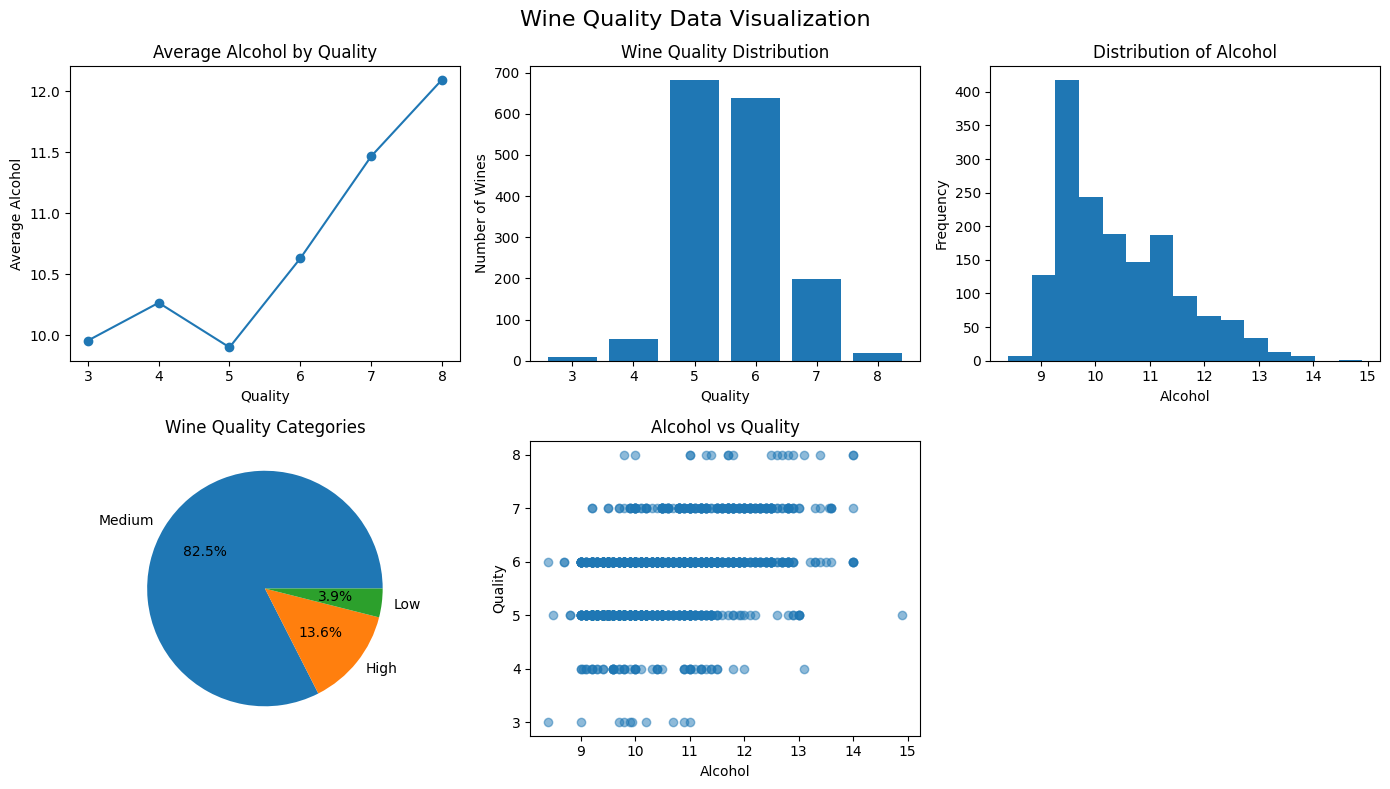

In [ ]:
#P20
import pandas as pd
import matplotlib.pyplot as plt

# Load dataset
df = pd.read_csv("winequality-red.csv", sep=";")

# Create figure and subplots
fig, ax = plt.subplots(2, 3, figsize=(14, 8))

# 1. Line Plot
avg_alcohol = df.groupby("quality")["alcohol"].mean()

ax[0, 0].plot(avg_alcohol.index, avg_alcohol.values, marker="o")
ax[0, 0].set_title("Average Alcohol by Quality")
ax[0, 0].set_xlabel("Quality")
ax[0, 0].set_ylabel("Average Alcohol")

# 2. Bar Chart
quality_count = df["quality"].value_counts().sort_index()

ax[0, 1].bar(quality_count.index, quality_count.values)
ax[0, 1].set_title("Wine Quality Distribution")
ax[0, 1].set_xlabel("Quality")
ax[0, 1].set_ylabel("Number of Wines")

# 3. Histogram
ax[0, 2].hist(df["alcohol"], bins=15)
ax[0, 2].set_title("Distribution of Alcohol")
ax[0, 2].set_xlabel("Alcohol")
ax[0, 2].set_ylabel("Frequency")

# 4. Pie Chart
quality_groups = pd.cut(
    df["quality"],
    bins=[0, 4, 6, 10],
    labels=["Low", "Medium", "High"]
)

group_count = quality_groups.value_counts()

ax[1, 0].pie(
    group_count.values,
    labels=group_count.index,
    autopct="%1.1f%%"
)
ax[1, 0].set_title("Wine Quality Categories")

# 5. Scatter Plot
ax[1, 1].scatter(df["alcohol"], df["quality"], alpha=0.5)
ax[1, 1].set_title("Alcohol vs Quality")
ax[1, 1].set_xlabel("Alcohol")
ax[1, 1].set_ylabel("Quality")

# Empty subplot
ax[1, 2].axis("off")

# Figure properties
fig.suptitle("Wine Quality Data Visualization", fontsize=16)
plt.tight_layout()

# Display
plt.show()

# New Section